In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# STEP 1: LOAD & INITIAL INSPECTION

df = pd.read_csv('saas_churn_dataset_raw.csv')

print(f' Shape: {df.shape}')
print(f'\n Data Types:\n{df.dtypes}')
print(f'\nMissing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nDuplicates:{df.duplicated().sum()}')
print(f'\nBasic Staats:{df.describe()}')

 Shape: (5030, 34)

 Data Types:
customer_id                    object
company_name                   object
industry                       object
company_size                   object
country                        object
signup_date                    object
subscription_plan              object
monthly_charges_usd           float64
contract_type                  object
tenure_months                 float64
total_logins_90d                int64
days_since_last_login           int64
avg_session_duration_min      float64
features_used_pct             float64
integrations_connected          int64
api_calls_30d                   int64
data_storage_used_pct         float64
reports_generated_30d           int64
team_members_active             int64
support_tickets_90d             int64
avg_ticket_resolution_hrs     float64
nps_score                     float64
csat_score                    float64
total_revenue_lifetime_usd    float64
payment_delays_6m               int64
discount_applied_

In [3]:
# STEP 2: REMOVE DUPLICATES
print(f'\n--- Removing Duplicates --')
print(f'Before: {df.shape[0]} rows')
df = df.drop_duplicates(subset='customer_id', keep='first')
print(f'After: {df.shape[0]} rows')
print(f'Removed: {5030 - df.shape[0]} duplicate rows')


--- Removing Duplicates --
Before: 5030 rows
After: 5000 rows
Removed: 30 duplicate rows


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 5000 non-null   object 
 1   company_name                5000 non-null   object 
 2   industry                    5000 non-null   object 
 3   company_size                5000 non-null   object 
 4   country                     5000 non-null   object 
 5   signup_date                 5000 non-null   object 
 6   subscription_plan           5000 non-null   object 
 7   monthly_charges_usd         5000 non-null   float64
 8   contract_type               5000 non-null   object 
 9   tenure_months               4980 non-null   float64
 10  total_logins_90d            5000 non-null   int64  
 11  days_since_last_login       5000 non-null   int64  
 12  avg_session_duration_min    4900 non-null   float64
 13  features_used_pct           5000 non-n

In [5]:
# STEP 3: FIX DATA TYPES
print(f'\n--- Fixing Data ---')

# tenure_months has "N/A" strings — convert to numeric
df['tenure_months'] = pd.to_numeric(df['tenure_months'], errors='coerce')
print(f'tnure months NAN after conversion: {df['tenure_months'].isnull().sum()}')


--- Fixing Data ---
tnure months NAN after conversion: 20


In [6]:
# Fill tenure NaN with median (safe central tendency)
median_tm = df['tenure_months'].median()
df['tenure_months'] = df['tenure_months'].fillna(median_tm).astype(int)
print(f'tenure monthhs filled with meadian: {median_tm}')

tenure monthhs filled with meadian: 18.0


In [7]:
# Dates
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['churn_date'] = pd.to_datetime(df['churn_date'], errors='coerce')

print(f'Date Columns Converted Successfully')

Date Columns Converted Successfully


In [8]:
df.head(50)

,customer_id,company_name,industry,company_size,country,signup_date,subscription_plan,monthly_charges_usd,contract_type,tenure_months,...,payment_delays_6m,discount_applied_pct,has_dedicated_csm,onboarding_completed,training_sessions_attended,engagement_score,health_score,churned,churn_date,churn_reason
0,CUST-00001,MediaSolutions_0,Retail,201-500,Canada,2024-05-10,Professional,77.52,Monthly,8,...,1,0,0,1,2,30.6,49.1,0,NaT,NaN
1,CUST-00002,RetailLabs_1,Legal,11-50,United Kingdom,2024-11-10,Enterprise,208.46,Annual,2,...,1,15,0,0,3,33.6,53.9,0,NaT,NaN
2,CUST-00003,FinanceCorp_2,Legal,11-50,India,2022-05-02,Professional,88.15,Annual,32,...,0,15,1,0,2,36.0,52.6,0,NaT,NaN
3,CUST-00004,MediaCloud_3,Technology,11-50,Canada,2023-04-12,Starter,28.01,Monthly,21,...,1,25,0,1,0,33.2,56.5,0,NaT,NaN
4,CUST-00005,MediaWorks_4,Logistics,1000+,Germany,2022-11-27,Professional,77.17,Monthly,25,...,0,25,0,1,1,31.5,51.0,0,NaT,NaN
5,CUST-00006,LogisticsSolutions_5,Finance,11-50,India,2022-03-29,Professional,75.54,Monthly,33,...,0,15,1,0,1,31.0,44.3,0,NaT,NaN
6,CUST-00007,TechInc_6,Consulting,51-200,United States,2024-05-21,Starter,42.24,Monthly,7,...,0,0,0,1,3,32.8,57.0,0,NaT,NaN
7,CUST-00008,FinanceLabs_7,Retail,501-1000,Germany,2022-05-11,Professional,78.66,Monthly,32,...,0,0,0,0,1,25.9,45.3,1,2024-08-04,Switched Internally
8,CUST-00009,EnergyWorks_8,Consulting,1-10,Brazil,2024-02-09,Enterprise,0.01,Annual,11,...,0,15,0,1,1,16.7,50.6,0,NaT,NaN
9,CUST-00010,TechCloud_9,Logistics,1000+,United States,2022-12-10,Enterprise,199.61,Monthly,25,...,0,20,0,1,2,28.4,50.4,0,NaT,NaN


In [9]:
# STEP 4: STANDARDIZE CATEGORICAL DATA
print(f"\n--- STANDARDIZING CATEGORIES ---")

# country standardization
country_mapping = {
    'UK': 'United Kingdom',
    'US': 'United States',
    'CANADA': 'Canada',
    'GERMANY': 'Germany',
    'india': 'India',
    'INDIA': 'India',
    'canada': 'Canada'
}
df['country'] = df['country'].replace(country_mapping)
print(f'Unique countries after fix: {df['country'].nunique()}')
print(f'Countries: {df['country'].unique()}')


--- STANDARDIZING CATEGORIES ---
Unique countries after fix: 10
Countries: ['Canada' 'United Kingdom' 'India' 'Germany' 'United States' 'Brazil'
 'Japan' 'Netherlands' 'France' 'Australia']


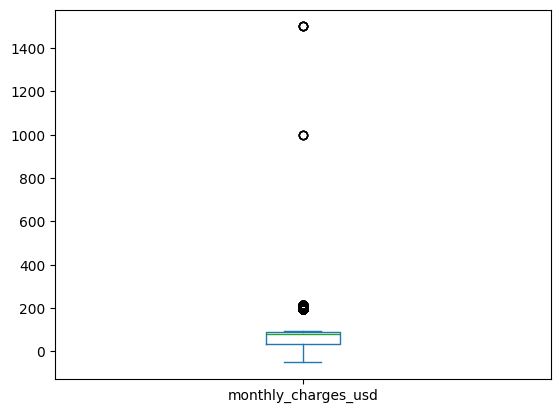

In [10]:
import matplotlib.pyplot as plt
df['monthly_charges_usd'].plot(kind='box')
plt.show()

In [11]:
Q1 = df['monthly_charges_usd'].quantile(0.25)
Q3 = df['monthly_charges_usd'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['monthly_charges_usd'] < lower) | (df['monthly_charges_usd'] > upper)]
print(outliers)

     customer_id         company_name    industry company_size  \
1     CUST-00002         RetailLabs_1       Legal        11-50   
9     CUST-00010          TechCloud_9   Logistics        1000+   
17    CUST-00018      EducationInc_17  Technology      201-500   
18    CUST-00019      MediaSystems_18     Finance        11-50   
20    CUST-00021    EducationWorks_20   Logistics       51-200   
...          ...                  ...         ...          ...   
4974  CUST-04975      MediaWorks_4974  Healthcare       51-200   
4975  CUST-04976   EducationCorp_4975  Technology        1000+   
4981  CUST-04982  LogisticsCloud_4981       Media       51-200   
4985  CUST-04986      HealthCorp_4985  Healthcare     501-1000   
4996  CUST-04997       RetailInc_4996      Energy        1000+   

             country signup_date subscription_plan  monthly_charges_usd  \
1     United Kingdom  2024-11-10        Enterprise               208.46   
9      United States  2022-12-10        Enterprise       

In [12]:
# STEP 5: HANDLE OUTLIERS
print(f"\n--- HANDLING OUTLIERS ---")

# Monthly charges — remove negatives and extreme values
print(f'Monthly Charges Before:'
      f'{df['monthly_charges_usd'].min()} to {df['monthly_charges_usd'].max()}')

# Business logic: Free=0, max Enterprise = ~250
df.loc[df['monthly_charges_usd'] < 0, 'monthly_charges_usd'] = np.nan
df.loc[df['monthly_charges_usd'] > 300, 'monthly_charges_usd'] = np.nan

# Fill outlier NaN with plan-based median
plan_median = df.groupby('subscription_plan')['monthly_charges_usd'].median()

for plan in df['subscription_plan'].unique():
    mask = (df['subscription_plan'] == plan) & (df['monthly_charges_usd'].isnull())
    df.loc[mask, 'monthly_charges_usd'] = plan_median[plan]

print(f"Monthly charges range AFTER: "
      f"{df['monthly_charges_usd'].min()} to {df['monthly_charges_usd'].max()}")


--- HANDLING OUTLIERS ---
Monthly Charges Before:-50.0 to 1500.0
Monthly charges range AFTER: 0.0 to 213.99


In [13]:
# STEP 6: HANDLE MISSING VALUES
print(f'\n--- Handling Missing Values ---')
print(f'Missing Before: {df.isnull().sum()[df.isnull().sum() > 0]}')

# NPS Score — fill with median (ordinal scale)
df['nps_score'] = df['nps_score'].fillna(df['nps_score'].median())

# CSAT Score — fill with median
df['csat_score'] = df['csat_score'].fillna(df['csat_score'].median())

# Average session duratio — fill with median by plan
for plan in df['subscription_plan'].unique():
    mask = (df['subscription_plan'] == plan) & (df['avg_session_duration_min'].isnull())
    plan_median = df.loc[df['subscription_plan'] == plan, 'avg_session_duration_min'].median()
    df.loc[mask, 'avg_session_duration_min'] = plan_median

# Avg ticket resolution — fill with overall median
df['avg_ticket_resolution_hrs'] = df['avg_ticket_resolution_hrs'].fillna(df['avg_ticket_resolution_hrs'].median())

print(f'\n--- Missing After: {df.isnull().sum()[df.isnull().sum() > 0]}')


--- Handling Missing Values ---
Missing Before: avg_session_duration_min      100
avg_ticket_resolution_hrs     120
nps_score                     200
csat_score                    150
churn_date                   4280
churn_reason                 4280
dtype: int64

--- Missing After: churn_date      4280
churn_reason    4280
dtype: int64


In [14]:
# STEP 7: FEATURE ENGINEERING (Senior-Level Thinking)
print(f"\n--- FEATURE ENGINEERING ---")

# 1. Revenue Risk = monthly_charges * churn_probability_proxy
df['revenue_at_risk'] = np.where(
    df['churned'] == 1,
    df['monthly_charges_usd'] * 12,
    0
)


--- FEATURE ENGINEERING ---


In [15]:
df.head(10)

,customer_id,company_name,industry,company_size,country,signup_date,subscription_plan,monthly_charges_usd,contract_type,tenure_months,...,discount_applied_pct,has_dedicated_csm,onboarding_completed,training_sessions_attended,engagement_score,health_score,churned,churn_date,churn_reason,revenue_at_risk
0,CUST-00001,MediaSolutions_0,Retail,201-500,Canada,2024-05-10,Professional,77.52,Monthly,8,...,0,0,1,2,30.6,49.1,0,NaT,NaN,0.00
1,CUST-00002,RetailLabs_1,Legal,11-50,United Kingdom,2024-11-10,Enterprise,208.46,Annual,2,...,15,0,0,3,33.6,53.9,0,NaT,NaN,0.00
2,CUST-00003,FinanceCorp_2,Legal,11-50,India,2022-05-02,Professional,88.15,Annual,32,...,15,1,0,2,36.0,52.6,0,NaT,NaN,0.00
3,CUST-00004,MediaCloud_3,Technology,11-50,Canada,2023-04-12,Starter,28.01,Monthly,21,...,25,0,1,0,33.2,56.5,0,NaT,NaN,0.00
4,CUST-00005,MediaWorks_4,Logistics,1000+,Germany,2022-11-27,Professional,77.17,Monthly,25,...,25,0,1,1,31.5,51.0,0,NaT,NaN,0.00
5,CUST-00006,LogisticsSolutions_5,Finance,11-50,India,2022-03-29,Professional,75.54,Monthly,33,...,15,1,0,1,31.0,44.3,0,NaT,NaN,0.00
6,CUST-00007,TechInc_6,Consulting,51-200,United States,2024-05-21,Starter,42.24,Monthly,7,...,0,0,1,3,32.8,57.0,0,NaT,NaN,0.00
7,CUST-00008,FinanceLabs_7,Retail,501-1000,Germany,2022-05-11,Professional,78.66,Monthly,32,...,0,0,0,1,25.9,45.3,1,2024-08-04,Switched Internally,943.92
8,CUST-00009,EnergyWorks_8,Consulting,1-10,Brazil,2024-02-09,Enterprise,0.01,Annual,11,...,15,0,1,1,16.7,50.6,0,NaT,NaN,0.00
9,CUST-00010,TechCloud_9,Logistics,1000+,United States,2022-12-10,Enterprise,199.61,Monthly,25,...,20,0,1,2,28.4,50.4,0,NaT,NaN,0.00


In [16]:
# 2. Customer Lifetime (months from signup to churn or today)
reference_days = pd.to_datetime('2025-01-01')
df['customer_lifetime_days'] = np.where(
    df['churn_date'].notna(),
    (df['churn_date'] - df['signup_date']).dt.days,
    (reference_days - df['signup_date']).dt.days
)
df.head(10)

,customer_id,company_name,industry,company_size,country,signup_date,subscription_plan,monthly_charges_usd,contract_type,tenure_months,...,has_dedicated_csm,onboarding_completed,training_sessions_attended,engagement_score,health_score,churned,churn_date,churn_reason,revenue_at_risk,customer_lifetime_days
0,CUST-00001,MediaSolutions_0,Retail,201-500,Canada,2024-05-10,Professional,77.52,Monthly,8,...,0,1,2,30.6,49.1,0,NaT,NaN,0.00,236.0
1,CUST-00002,RetailLabs_1,Legal,11-50,United Kingdom,2024-11-10,Enterprise,208.46,Annual,2,...,0,0,3,33.6,53.9,0,NaT,NaN,0.00,52.0
2,CUST-00003,FinanceCorp_2,Legal,11-50,India,2022-05-02,Professional,88.15,Annual,32,...,1,0,2,36.0,52.6,0,NaT,NaN,0.00,975.0
3,CUST-00004,MediaCloud_3,Technology,11-50,Canada,2023-04-12,Starter,28.01,Monthly,21,...,0,1,0,33.2,56.5,0,NaT,NaN,0.00,630.0
4,CUST-00005,MediaWorks_4,Logistics,1000+,Germany,2022-11-27,Professional,77.17,Monthly,25,...,0,1,1,31.5,51.0,0,NaT,NaN,0.00,766.0
5,CUST-00006,LogisticsSolutions_5,Finance,11-50,India,2022-03-29,Professional,75.54,Monthly,33,...,1,0,1,31.0,44.3,0,NaT,NaN,0.00,1009.0
6,CUST-00007,TechInc_6,Consulting,51-200,United States,2024-05-21,Starter,42.24,Monthly,7,...,0,1,3,32.8,57.0,0,NaT,NaN,0.00,225.0
7,CUST-00008,FinanceLabs_7,Retail,501-1000,Germany,2022-05-11,Professional,78.66,Monthly,32,...,0,0,1,25.9,45.3,1,2024-08-04,Switched Internally,943.92,816.0
8,CUST-00009,EnergyWorks_8,Consulting,1-10,Brazil,2024-02-09,Enterprise,0.01,Annual,11,...,0,1,1,16.7,50.6,0,NaT,NaN,0.00,327.0
9,CUST-00010,TechCloud_9,Logistics,1000+,United States,2022-12-10,Enterprise,199.61,Monthly,25,...,0,1,2,28.4,50.4,0,NaT,NaN,0.00,753.0


In [17]:
# 3. Login Frequency Category
df['login_frequency'] = pd.cut(
    df['total_logins_90d'],
    bins=[0,5,15,40,200],
    labels= ['Dormant', 'Medium', 'High', 'Very High'],
    include_lowest= True
)
df.head(10)

,customer_id,company_name,industry,company_size,country,signup_date,subscription_plan,monthly_charges_usd,contract_type,tenure_months,...,onboarding_completed,training_sessions_attended,engagement_score,health_score,churned,churn_date,churn_reason,revenue_at_risk,customer_lifetime_days,login_frequency
0,CUST-00001,MediaSolutions_0,Retail,201-500,Canada,2024-05-10,Professional,77.52,Monthly,8,...,1,2,30.6,49.1,0,NaT,NaN,0.00,236.0,High
1,CUST-00002,RetailLabs_1,Legal,11-50,United Kingdom,2024-11-10,Enterprise,208.46,Annual,2,...,0,3,33.6,53.9,0,NaT,NaN,0.00,52.0,High
2,CUST-00003,FinanceCorp_2,Legal,11-50,India,2022-05-02,Professional,88.15,Annual,32,...,0,2,36.0,52.6,0,NaT,NaN,0.00,975.0,High
3,CUST-00004,MediaCloud_3,Technology,11-50,Canada,2023-04-12,Starter,28.01,Monthly,21,...,1,0,33.2,56.5,0,NaT,NaN,0.00,630.0,High
4,CUST-00005,MediaWorks_4,Logistics,1000+,Germany,2022-11-27,Professional,77.17,Monthly,25,...,1,1,31.5,51.0,0,NaT,NaN,0.00,766.0,High
5,CUST-00006,LogisticsSolutions_5,Finance,11-50,India,2022-03-29,Professional,75.54,Monthly,33,...,0,1,31.0,44.3,0,NaT,NaN,0.00,1009.0,Very High
6,CUST-00007,TechInc_6,Consulting,51-200,United States,2024-05-21,Starter,42.24,Monthly,7,...,1,3,32.8,57.0,0,NaT,NaN,0.00,225.0,High
7,CUST-00008,FinanceLabs_7,Retail,501-1000,Germany,2022-05-11,Professional,78.66,Monthly,32,...,0,1,25.9,45.3,1,2024-08-04,Switched Internally,943.92,816.0,High
8,CUST-00009,EnergyWorks_8,Consulting,1-10,Brazil,2024-02-09,Enterprise,0.01,Annual,11,...,1,1,16.7,50.6,0,NaT,NaN,0.00,327.0,Very High
9,CUST-00010,TechCloud_9,Logistics,1000+,United States,2022-12-10,Enterprise,199.61,Monthly,25,...,1,2,28.4,50.4,0,NaT,NaN,0.00,753.0,High


In [18]:
# 4. Customer Segment by health_score
df['risk_sagment'] = pd.cut(
    df['health_score'],
    bins=[0,30,50,70,100],
    labels=['Critical', 'At Risk', 'Stable', 'Healthy'],
    include_lowest=True
)

In [19]:
# 5. NPS Category
df['nps_category'] = pd.cut(
    df['nps_score'],
    bins=[-1,6,8,10],
    labels=['Detractor', 'Passive', 'Promoter']
)

In [20]:
# 6. Support Burden (tickets per month of tenure)
df['support_burden'] = np.round(
    df['support_tickets_90d'] / np.maximum(df['tenure_months'], 1),
    3
)

In [21]:
# 7. Revenue per team member
df['revenue_per_member'] = np.round(
    df['monthly_charges_usd'] / np.maximum(df['team_members_active'],1),
    2
)

In [22]:
# 8. Is High Value Customer
df['is_high_value'] = np.where(
    df['monthly_charges_usd'] >= 79,
    1,
    0
)

In [23]:
# 9. Signup Year and Month (for trend analysis)
df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.month
df['signup_quater'] = df['signup_date'].dt.quarter

In [24]:
# 10. Engagement Trend Proxy
df['engagmet_vs_tenure'] = np.round(
    df['engagement_score'] / np.maximum(df['tenure_months'], 1),
    2
)

print(f"New features created: 10 additional columns")
print(f"Final shape: {df.shape}")
print(f"Final columns: {list(df.columns)}")

New features created: 10 additional columns
Final shape: (5000, 46)
Final columns: ['customer_id', 'company_name', 'industry', 'company_size', 'country', 'signup_date', 'subscription_plan', 'monthly_charges_usd', 'contract_type', 'tenure_months', 'total_logins_90d', 'days_since_last_login', 'avg_session_duration_min', 'features_used_pct', 'integrations_connected', 'api_calls_30d', 'data_storage_used_pct', 'reports_generated_30d', 'team_members_active', 'support_tickets_90d', 'avg_ticket_resolution_hrs', 'nps_score', 'csat_score', 'total_revenue_lifetime_usd', 'payment_delays_6m', 'discount_applied_pct', 'has_dedicated_csm', 'onboarding_completed', 'training_sessions_attended', 'engagement_score', 'health_score', 'churned', 'churn_date', 'churn_reason', 'revenue_at_risk', 'customer_lifetime_days', 'login_frequency', 'risk_sagment', 'nps_category', 'support_burden', 'revenue_per_member', 'is_high_value', 'signup_year', 'signup_month', 'signup_quater', 'engagmet_vs_tenure']


In [25]:
# STEP 8: VALIDATION

print(f"FINAL VALIDATION")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Duplicates: {df.duplicated(subset='customer_id').sum()}")
print(f"Missing values: {df.isnull().sum().sum()} "
      f"(excluding churn_date/churn_reason for non-churned)")
print(f"Churn rate: {df['churned'].mean()*100:.1f}%")
print(f"Churned count: {df['churned'].sum()}")
print(f"Active count: {(df['churned']==0).sum()}")
print(f"Data types:\n{df.dtypes}")

FINAL VALIDATION
Total rows: 5000
Total columns: 46
Duplicates: 0
Missing values: 8560 (excluding churn_date/churn_reason for non-churned)
Churn rate: 14.4%
Churned count: 720
Active count: 4280
Data types:
customer_id                           object
company_name                          object
industry                              object
company_size                          object
country                               object
signup_date                   datetime64[ns]
subscription_plan                     object
monthly_charges_usd                  float64
contract_type                         object
tenure_months                          int64
total_logins_90d                       int64
days_since_last_login                  int64
avg_session_duration_min             float64
features_used_pct                    float64
integrations_connected                 int64
api_calls_30d                          int64
data_storage_used_pct                float64
reports_generated_30d       

In [26]:
df.isnull().sum()

customer_id                      0
company_name                     0
industry                         0
company_size                     0
country                          0
signup_date                      0
subscription_plan                0
monthly_charges_usd              0
contract_type                    0
tenure_months                    0
total_logins_90d                 0
days_since_last_login            0
avg_session_duration_min         0
features_used_pct                0
integrations_connected           0
api_calls_30d                    0
data_storage_used_pct            0
reports_generated_30d            0
team_members_active              0
support_tickets_90d              0
avg_ticket_resolution_hrs        0
nps_score                        0
csat_score                       0
total_revenue_lifetime_usd       0
payment_delays_6m                0
discount_applied_pct             0
has_dedicated_csm                0
onboarding_completed             0
training_sessions_at

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### CHURN OVERVIEW

In [28]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

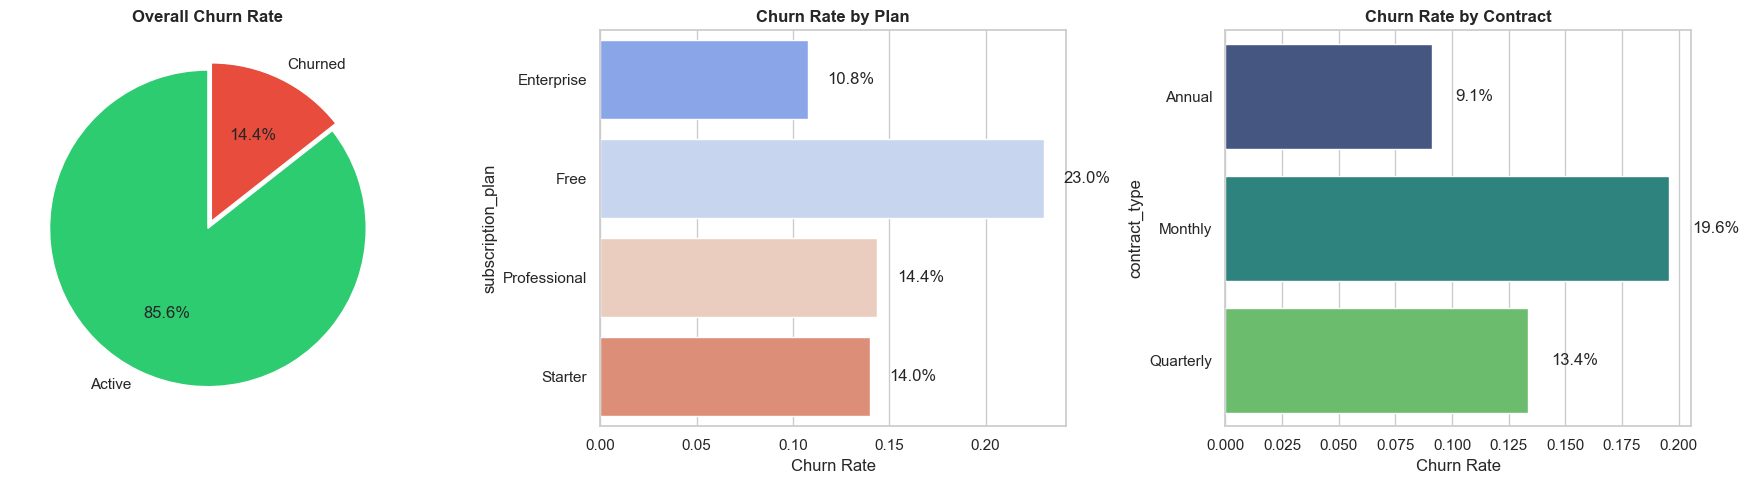

In [29]:
sns.set(style="whitegrid")  # clean background

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 🔹 1a. Churn Distribution (Pie - matplotlib)
churn_counts = df['churned'].value_counts()
axes[0].pie(churn_counts,
            labels=['Active', 'Churned'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            explode=(0, 0.05))
axes[0].set_title('Overall Churn Rate', fontweight='bold')


# 🔹 1b. Churn by Plan (Seaborn)
churn_by_plan = df.groupby('subscription_plan')['churned'].mean().reset_index()

sns.barplot(data=churn_by_plan,
            y='subscription_plan',
            x='churned',
            palette='coolwarm',
            ax=axes[1])

axes[1].set_title('Churn Rate by Plan', fontweight='bold')
axes[1].set_xlabel('Churn Rate')

# Add labels
for i, v in enumerate(churn_by_plan['churned']):
    axes[1].text(v + 0.01, i, f'{v*100:.1f}%', va='center')


# 🔹 1c. Churn by Contract (Seaborn)
churn_by_contract = df.groupby('contract_type')['churned'].mean().reset_index()

sns.barplot(data=churn_by_contract,
            y='contract_type',
            x='churned',
            palette='viridis',
            ax=axes[2])

axes[2].set_title('Churn Rate by Contract', fontweight='bold')
axes[2].set_xlabel('Churn Rate')

# Add labels
for i, v in enumerate(churn_by_contract['churned']):
    axes[2].text(v + 0.01, i, f'{v*100:.1f}%', va='center')


plt.tight_layout()
plt.show()

### BEHAVIORAL ANALYSIS — CHURNED vs ACTIVE

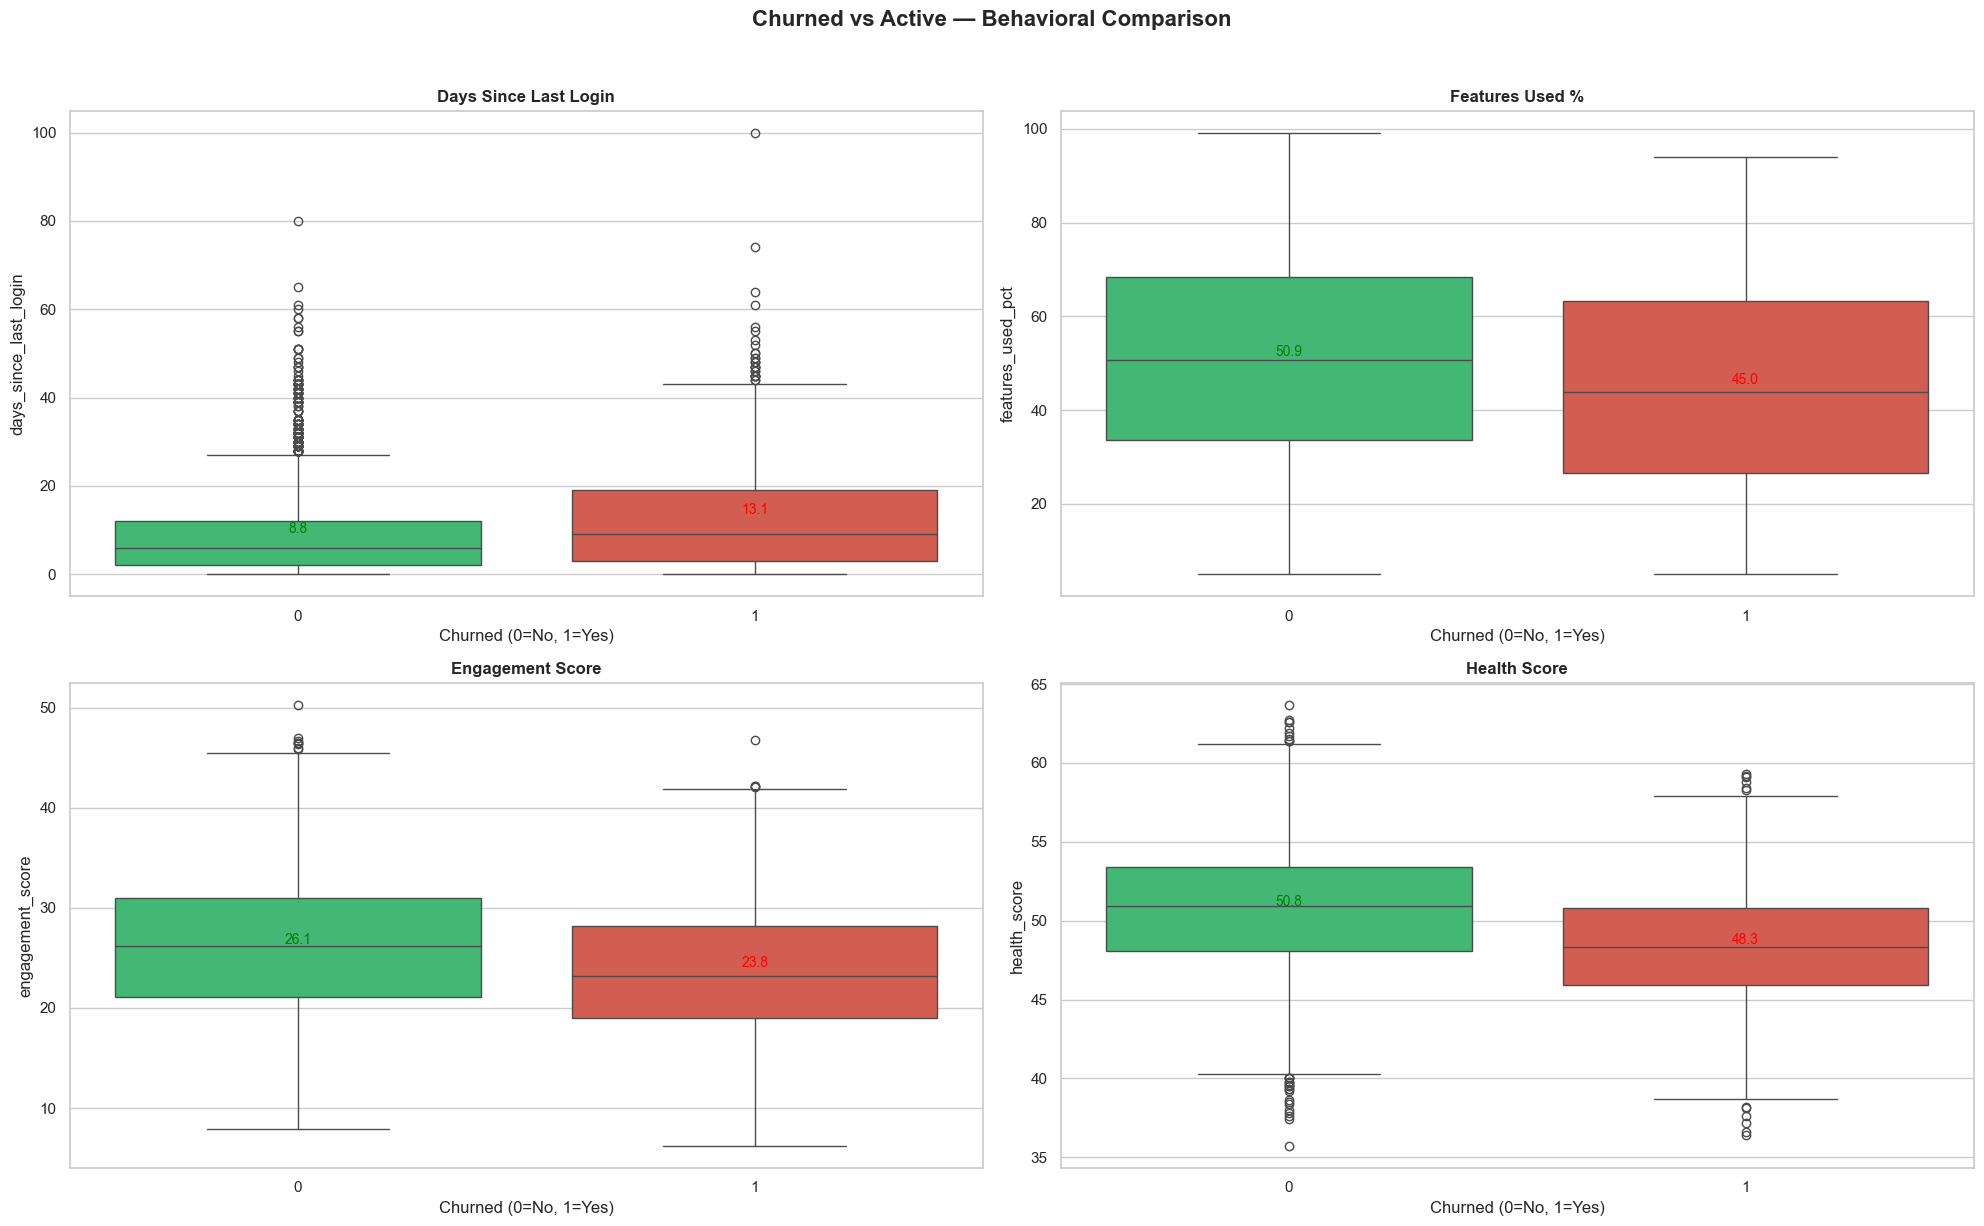

In [30]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

compare_cols = ['days_since_last_login', 'features_used_pct',
                'engagement_score', 'health_score']
titles = ['Days Since Last Login', 'Features Used %',
          'Engagement Score', 'Health Score']
for idx, (col, title) in enumerate(zip(compare_cols, titles)):
    ax = axes[idx // 2][idx % 2]
    # 🔹 Seaborn boxplot
    sns.boxplot(data=df,
                x='churned',
                y=col,
                palette=['#2ecc71', '#e74c3c'],
                ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Churned (0=No, 1=Yes)')
    ax.set_ylabel(col)
    # 🔹 Add mean annotations
    means = df.groupby('churned')[col].mean()
    ax.text(0, means[0], f'{means[0]:.1f}',
            ha='center', va='bottom', fontsize=10, color='green')
    ax.text(1, means[1], f'{means[1]:.1f}',
            ha='center', va='bottom', fontsize=10, color='red')
plt.suptitle('Churned vs Active — Behavioral Comparison',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### CORRELATION ANALYSIS

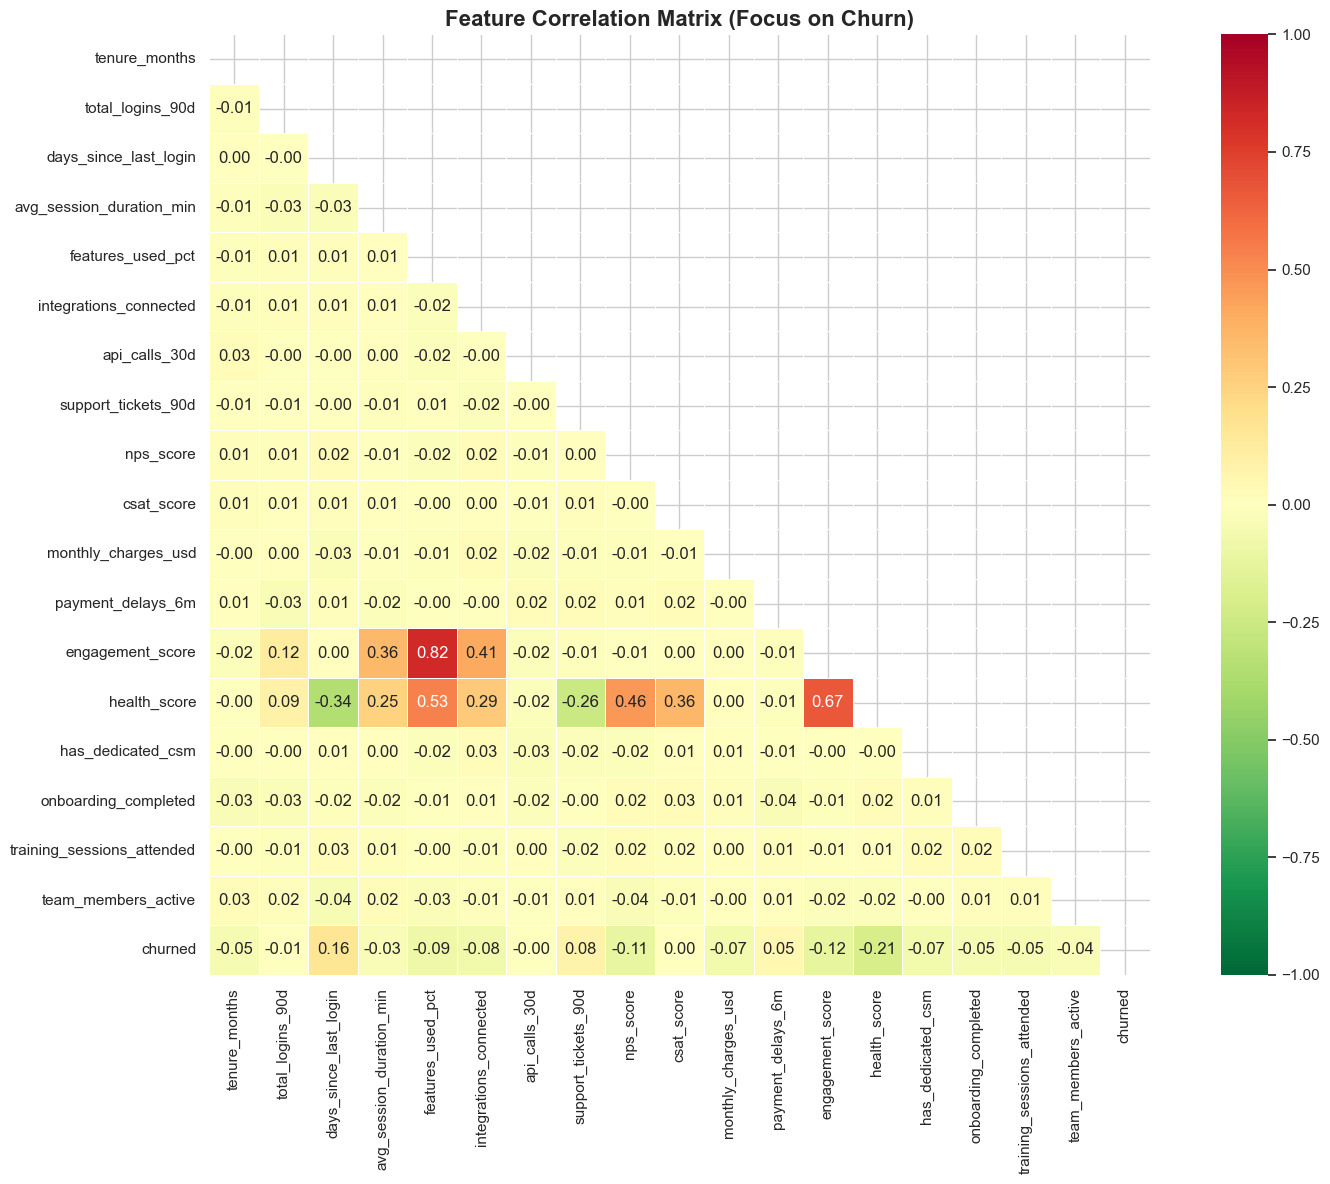

In [31]:
fig, ax = plt.subplots(figsize=(16, 12))

numeric_cols = ['tenure_months', 'total_logins_90d', 'days_since_last_login',
                'avg_session_duration_min', 'features_used_pct',
                'integrations_connected', 'api_calls_30d',
                'support_tickets_90d', 'nps_score', 'csat_score',
                'monthly_charges_usd', 'payment_delays_6m',
                'engagement_score', 'health_score',
                'has_dedicated_csm', 'onboarding_completed',
                'training_sessions_attended', 'team_members_active', 'churned']

corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            square=True,
            linewidths=0.5,
            vmin=-1, vmax=1,
            ax=ax)

ax.set_title('Feature Correlation Matrix (Focus on Churn)',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# Print top correlations with churn
print("\n" + "=" * 50)
print("TOP CORRELATIONS WITH CHURN")
print("=" * 50)
churn_corr = corr_matrix['churned'].drop('churned').sort_values()
print("\nPOSITIVE (increases churn):")
print(churn_corr.tail(5))
print("\nNEGATIVE (decreases churn):")
print(churn_corr.head(5))


TOP CORRELATIONS WITH CHURN

POSITIVE (increases churn):
api_calls_30d           -0.000397
csat_score               0.001193
payment_delays_6m        0.048621
support_tickets_90d      0.077459
days_since_last_login    0.156562
Name: churned, dtype: float64

NEGATIVE (decreases churn):
health_score             -0.210510
engagement_score         -0.122357
nps_score                -0.113655
features_used_pct        -0.093131
integrations_connected   -0.076204
Name: churned, dtype: float64


### CHURN BY INDUSTRY & COMPANY SIZE

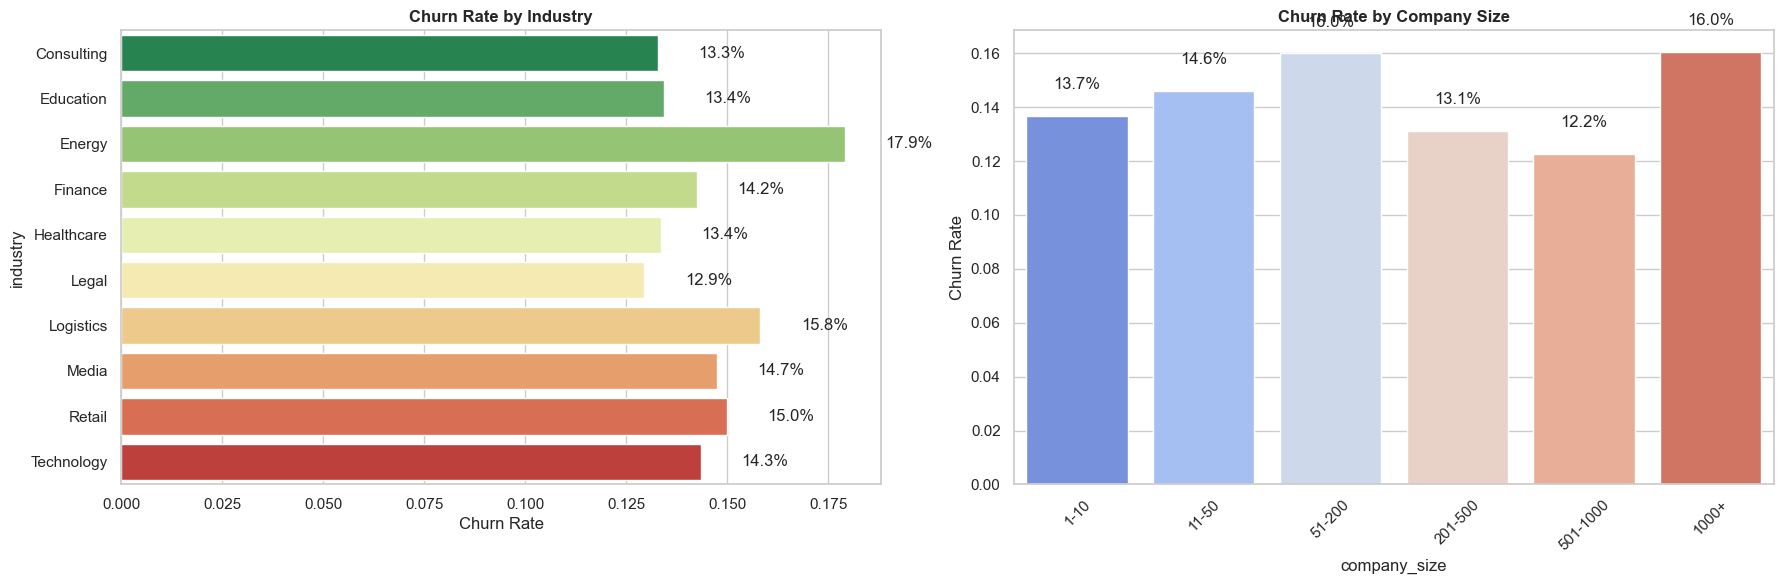

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Industry
churn_industry = df.groupby('industry')['churned'].mean().reset_index()

sns.barplot(data=churn_industry,
            y='industry',
            x='churned',
            palette='RdYlGn_r',
            ax=axes[0])

axes[0].set_title('Churn Rate by Industry', fontweight='bold')
axes[0].set_xlabel('Churn Rate')

for i, v in enumerate(churn_industry['churned']):
    axes[0].text(v + 0.01, i, f'{v*100:.1f}%', va='center')


# Company Size
size_order = ['1-10', '11-50', '51-200', '201-500', '501-1000', '1000+']
churn_size = df.groupby('company_size')['churned'].mean().reindex(size_order).reset_index()

sns.barplot(data=churn_size,
            x='company_size',
            y='churned',
            palette='coolwarm',
            ax=axes[1])

axes[1].set_title('Churn Rate by Company Size', fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(churn_size['churned']):
    axes[1].text(i, v + 0.01, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.show()

### CHURN REASON ANALYSIS

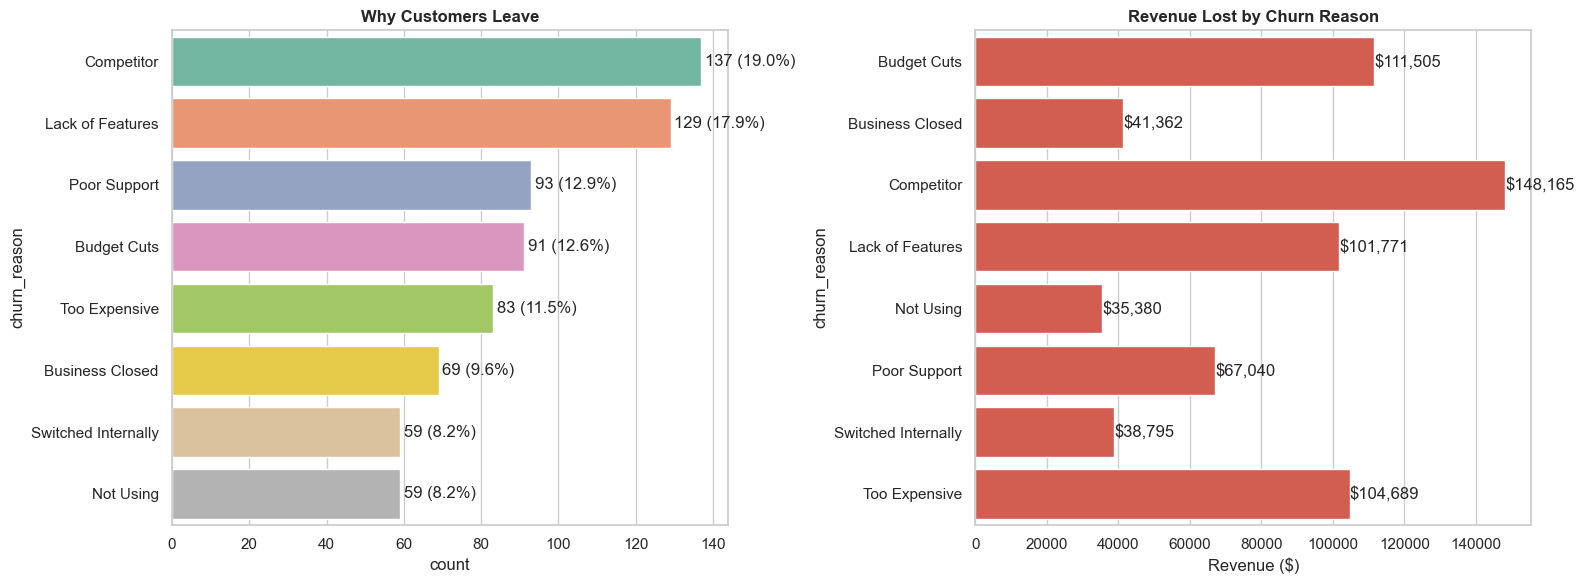

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

churned_df = df[df['churned'] == 1]

# Churn Reasons
reason_counts = churned_df['churn_reason'].value_counts().reset_index()
reason_counts.columns = ['churn_reason', 'count']

sns.barplot(data=reason_counts,
            y='churn_reason',
            x='count',
            palette='Set2',
            ax=axes[0])

axes[0].set_title('Why Customers Leave', fontweight='bold')

for i, v in enumerate(reason_counts['count']):
    pct = v / reason_counts['count'].sum() * 100
    axes[0].text(v + 1, i, f'{v} ({pct:.1f}%)', va='center')


# Revenue by Reason
revenue_by_reason = churned_df.groupby('churn_reason')['revenue_at_risk'].sum().reset_index()

sns.barplot(data=revenue_by_reason,
            y='churn_reason',
            x='revenue_at_risk',
            color='#e74c3c',
            ax=axes[1])

axes[1].set_title('Revenue Lost by Churn Reason', fontweight='bold')
axes[1].set_xlabel('Revenue ($)')

for i, v in enumerate(revenue_by_reason['revenue_at_risk']):
    axes[1].text(v + 50, i, f'${v:,.0f}', va='center')

plt.tight_layout()
plt.show()

### KEY BUSINESS METRICS SUMMARY

In [35]:
total_customers = len(df)
churned_count = df['churned'].sum()
churn_rate = df['churned'].mean()
total_revenue_at_risk = churned_df['revenue_at_risk'].sum()
avg_revenue_churned = churned_df['monthly_charges_usd'].mean()
avg_revenue_active = df[df['churned']==0]['monthly_charges_usd'].mean()
avg_tenure_churned = churned_df['tenure_months'].mean()
avg_tenure_active = df[df['churned']==0]['tenure_months'].mean()

print(f"Total Customers: {total_customers:,}")
print(f"Churned: {churned_count:,} ({churn_rate*100:.1f}%)")
print(f"Total Annual Revenue at Risk: ${total_revenue_at_risk:,.0f}")
print(f"Avg Monthly Revenue - Churned: ${avg_revenue_churned:.2f}")
print(f"Avg Monthly Revenue - Active: ${avg_revenue_active:.2f}")
print(f"Avg Tenure - Churned: {avg_tenure_churned:.0f} months")
print(f"Avg Tenure - Active: {avg_tenure_active:.0f} months")

Total Customers: 5,000
Churned: 720 (14.4%)
Total Annual Revenue at Risk: $648,708
Avg Monthly Revenue - Churned: $75.08
Avg Monthly Revenue - Active: $87.66
Avg Tenure - Churned: 17 months
Avg Tenure - Active: 18 months


In [36]:
# Segment risk
print(f"\n📋 RISK SEGMENTS:")
risk_summary = df.groupby('risk_sagment').agg(
    count=('churned', 'count'),
    churn_rate=('churned', 'mean'),
    avg_revenue=('monthly_charges_usd', 'mean')
).round(3)
print(risk_summary)


📋 RISK SEGMENTS:
              count  churn_rate  avg_revenue
risk_sagment                                
Critical          0         NaN          NaN
At Risk        2298       0.208       85.496
Stable         2702       0.090       86.142
Healthy           0         NaN          NaN


In [37]:
pip install pyodbc sqlalchemy

In [38]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=master;"
    "Trusted_Connection=yes;",
    autocommit=True   # 🔥 IMPORTANT FIX
)

cursor = conn.cursor()

cursor.execute("CREATE DATABASE saas_churn_db")

conn.close()

In [39]:
from sqlalchemy import create_engine

server = 'localhost\\SQLEXPRESS'
database = 'saas_churn_db'

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?trusted_connection=yes&driver=ODBC+Driver+17+for+SQL+Server"
)
df.to_sql("customers", engine, if_exists="replace", index=False)